<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **SpaceX  Falcon 9 First Stage Landing Prediction**


## Assignment: Exploring and Preparing Data


Estimated time needed: **70** minutes


In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage.

In this lab, you will perform Exploratory Data Analysis and Feature Engineering.


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planned. Space X performs a controlled landing in the oceans.


## Objectives

Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

*   Exploratory Data Analysis
*   Preparing Data  Feature Engineering


### Import Libraries and Define Auxiliary Functions


We will import the following libraries the lab


In [43]:
#import piplite
#await piplite.install(['numpy'])
#await piplite.install(['pandas'])
#await piplite.install(['seaborn'])

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Exploratory Data Analysis


First, let's read the SpaceX dataset into a Pandas dataframe and print its summary


#from js import fetch
#import io

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
#resp = await fetch(URL)
#dataset_part_2_csv = io.BytesIO((await resp.arrayBuffer()).to_py())
df=pd.read_csv(dataset_part_2_csv)
df.head(5)

In [45]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df = pd.read_csv(URL)
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass also appears to be a factor; even with more massive payloads, the first stage often returns successfully.


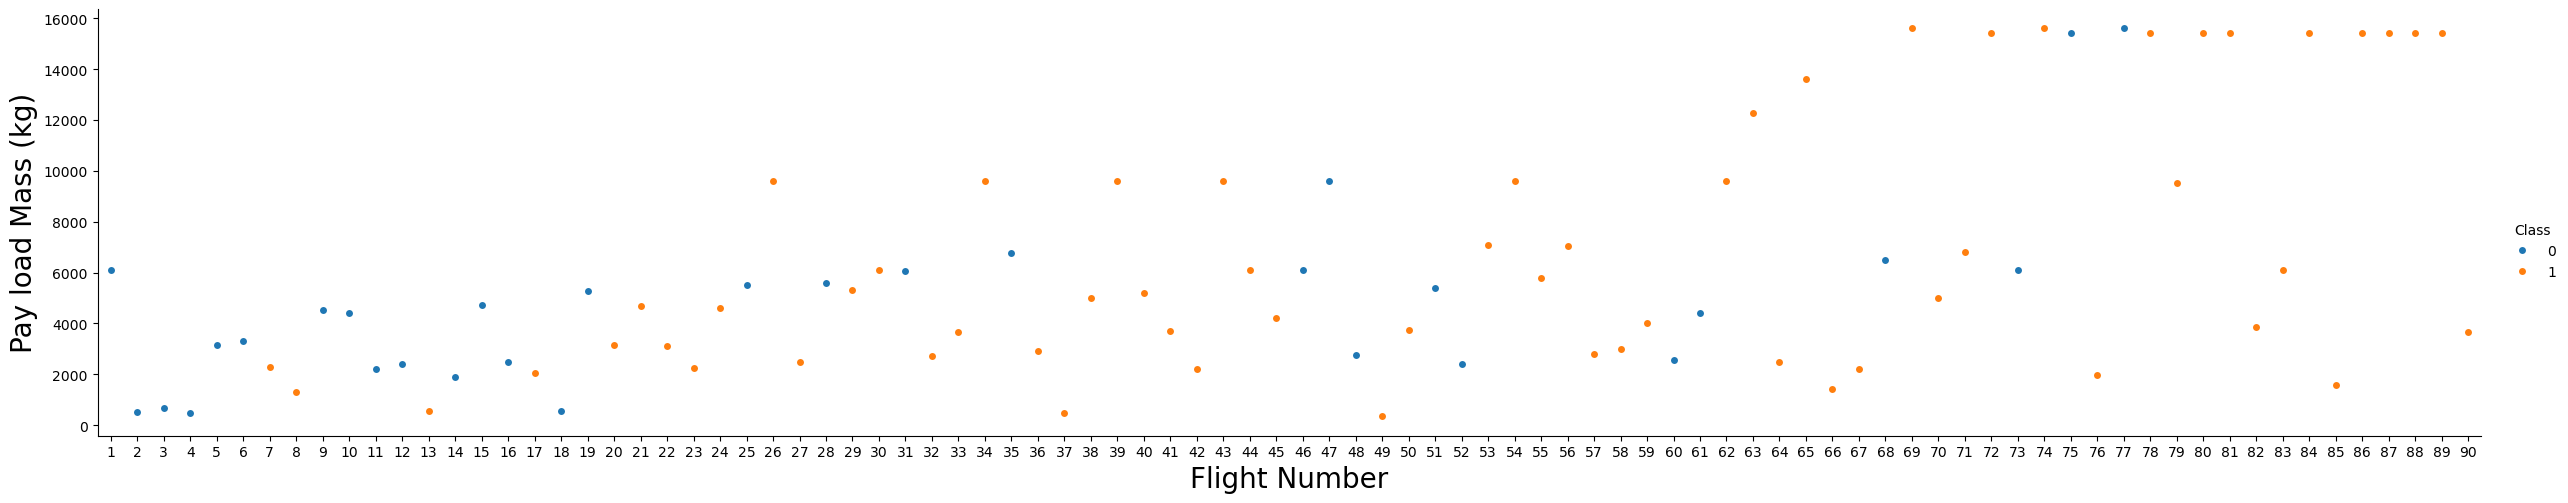

In [46]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

Next, let's drill down to each site visualize its detailed launch records.


### TASK 1: Visualize the relationship between Flight Number and Launch Site


Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>


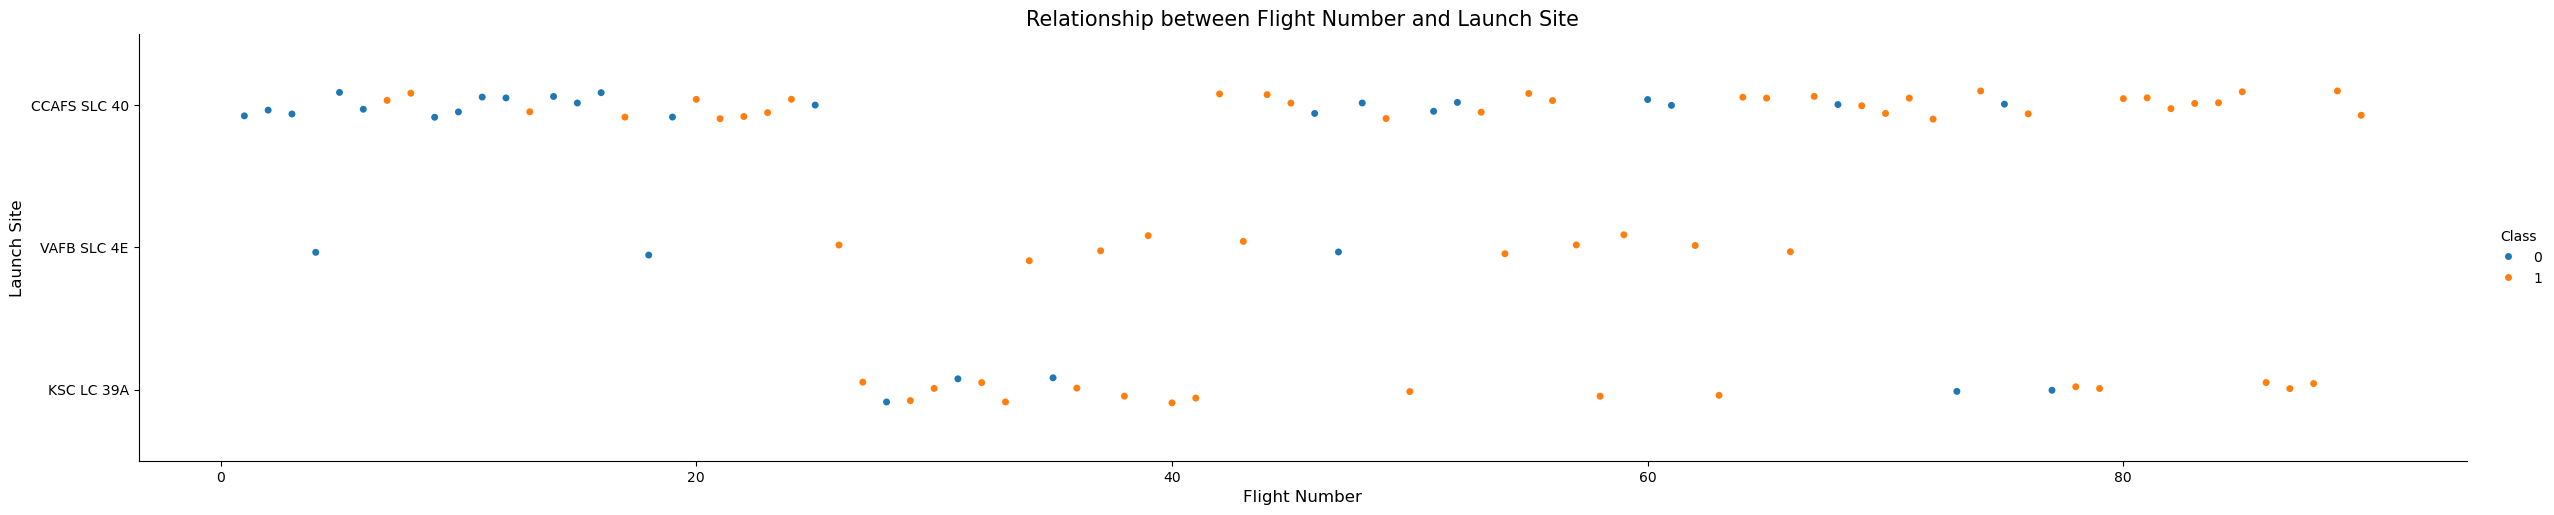

In [ ]:
sns.catplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=12)
plt.ylabel("Launch Site", fontsize=12)
plt.title("Relationship between Flight Number and Launch Site", fontsize=15)
plt.show()

Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.


### TASK 2: Visualize the relationship between Payload Mass and Launch Site


We also want to observe if there is any relationship between launch sites and their payload mass.


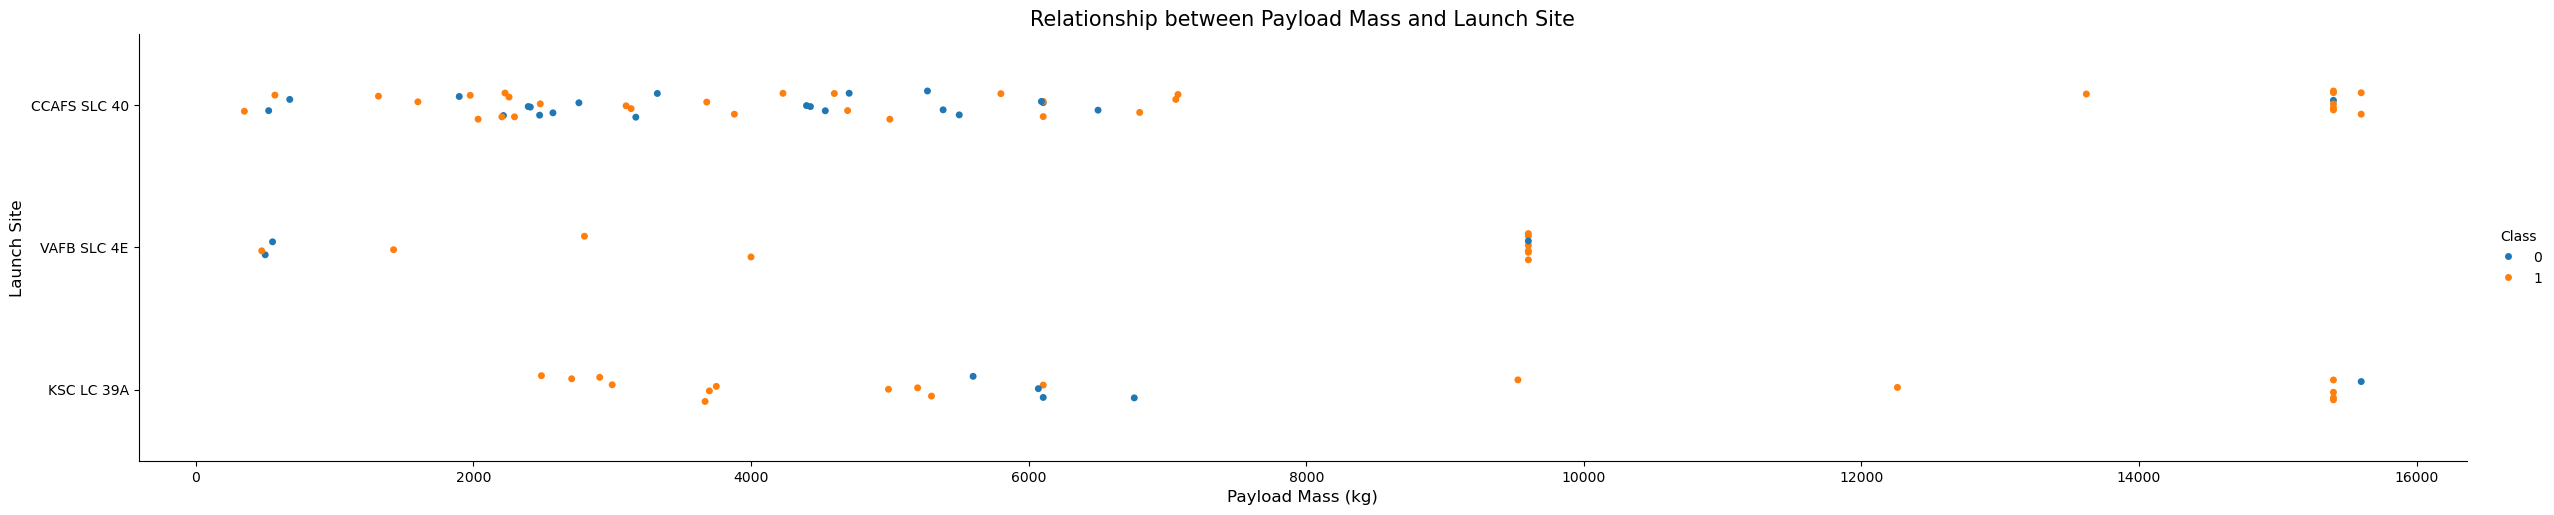

In [ ]:
sns.catplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df, aspect=5)

plt.xlabel("Payload Mass (kg)", fontsize=12)
plt.ylabel("Launch Site", fontsize=12)
plt.title("Relationship between Payload Mass and Launch Site", fontsize=15)
plt.show()

Now if you observe Payload Mass Vs. Launch Site scatter point chart you will find for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).


### TASK  3: Visualize the relationship between success rate of each orbit type


Next, we want to visually check if there are any relationship between success rate and orbit type.


Let's create a `bar chart` for the sucess rate of each orbit


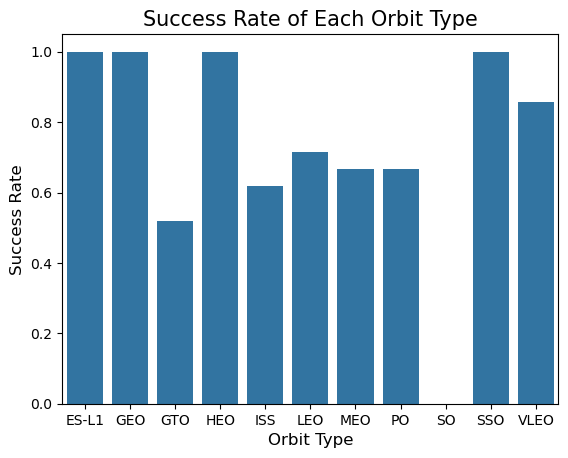

In [ ]:
orbit_success_rate = df.groupby('Orbit')['Class'].mean(). reset_index()
sns.barplot(x='Orbit', y='Class', data=orbit_success_rate)
plt.xlabel("Orbit Type", fontsize=12)
plt.ylabel("Success Rate", fontsize=12)
plt.title("Success Rate of Each Orbit Type", fontsize=15)
plt.show()

Analyze the plotted bar chart to identify which orbits have the highest success rates.


### TASK  4: Visualize the relationship between FlightNumber and Orbit type


For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.


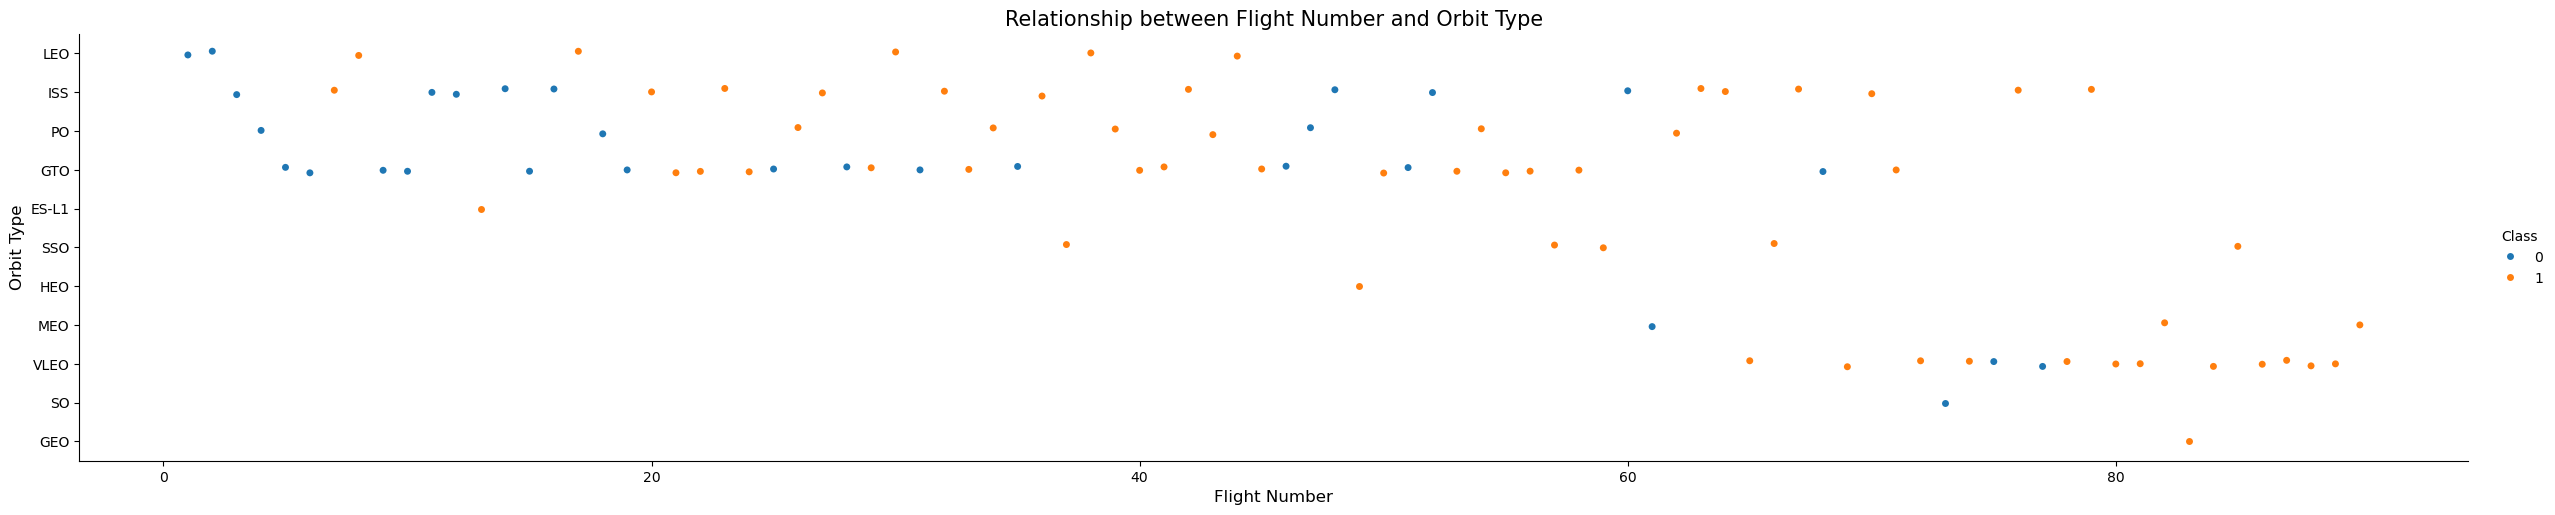

In [ ]:
sns.catplot(y="Orbit", x="FlightNumber", hue="Class", data=df, aspect= 5)
plt.xlabel("Flight Number", fontsize=12)
plt.ylabel("Orbit Type", fontsize=12)
plt.title("Relationship between Flight Number and Orbit Type", fontsize=15)
plt.show()

You can observe that in the LEO orbit, success seems to be related to the number of flights. Conversely, in the GTO orbit, there appears to be no relationship between flight number and success.


### TASK  5: Visualize the relationship between Payload Mass and Orbit type


Similarly, we can plot the Payload Mass vs. Orbit scatter point charts to reveal the relationship between Payload Mass and Orbit type


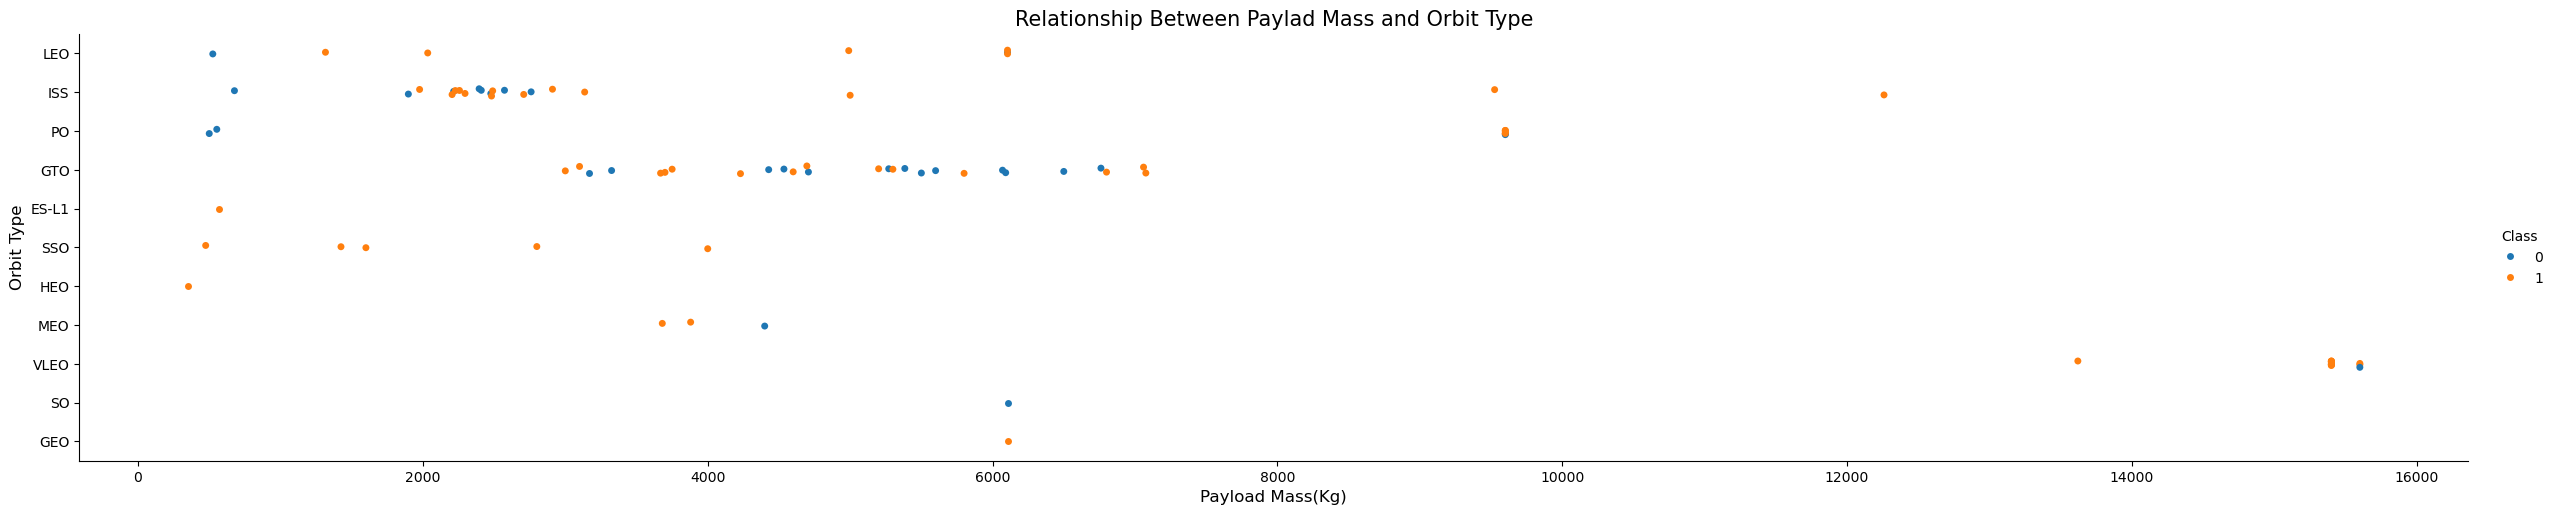

In [ ]:
plt.xlabel("Payload Mass(Kg)", fontsize=12)
plt.ylabel("Orbit Type", fontsize=12)
plt.title("Relationship Between Paylad Mass and Orbit Type", fontsize=15)
plt.show()

With heavy payloads the successful landing or positive landing rate are more for Polar,LEO and ISS.

However, for GTO, it's difficult to distinguish between successful and unsuccessful landings as both outcomes are present.


### TASK  6: Visualize the launch success yearly trend


You can plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend.


The function will help you get the year from the date:


In [ ]:
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()
df['Date'] = year
df.head()
    

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


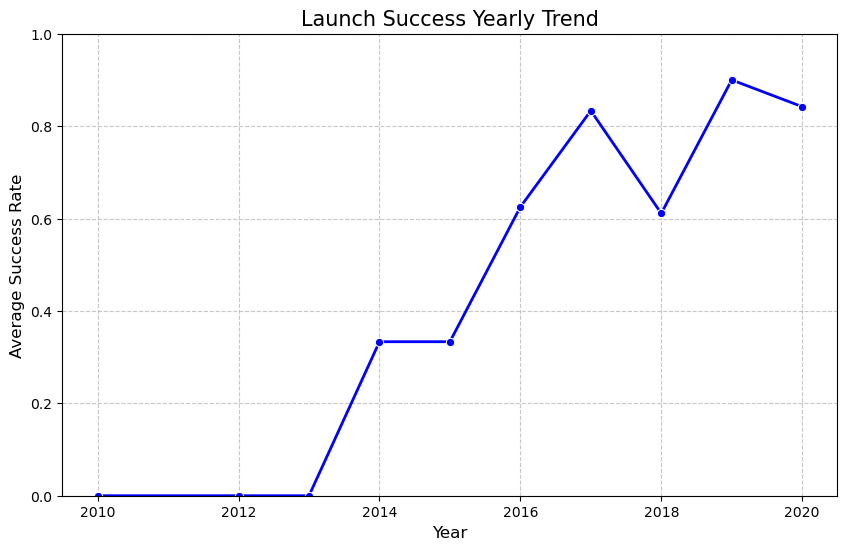

In [ ]:
df['Year']= pd.to_datetime(df['Date']).dt.year
yearly_success_rate = df.groupby('Year')['Class'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='Class', data=yearly_success_rate, marker='o', color='b', linewidth=2)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Success Rate", fontsize=12)
plt.title("Launch Success Yearly Trend", fontsize=15)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0,1)
plt.show()

you can observe that the sucess rate since 2013 kept increasing till 2020


## Features Engineering


By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.


In [54]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### TASK  7: Create dummy variables to categorical columns


Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.


In [ ]:

features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
features_one_hot.head()


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### TASK  8: Cast all numeric columns to `float64`


Now that our <code>features_one_hot</code> dataframe only contains numbers, cast the entire dataframe to variable type <code>float64</code>


In [ ]:

features_one_hot = features_one_hot.astype('float64')
print("Tipos de datos despues de la conversion:")
print(features_one_hot.dtypes)

features_one_hot.head()

Tipos de datos despues de la conversion:
FlightNumber    float64
PayloadMass     float64
Flights         float64
GridFins        float64
Reused          float64
                 ...   
Serial_B1056    float64
Serial_B1058    float64
Serial_B1059    float64
Serial_B1060    float64
Serial_B1062    float64
Length: 80, dtype: object


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:

unique_launch_sites = df['LaunchSite'].unique()
print(unique_launch_sites)

['CCAFS SLC 40' 'VAFB SLC 4E' 'KSC LC 39A']


In [ ]:

cca_launch_sites = df[df['LaunchSite'].str.startswith('CCA')].head(5)
print(cca_launch_sites)

   FlightNumber  Date BoosterVersion  PayloadMass Orbit    LaunchSite  \
0             1  2010       Falcon 9  6104.959412   LEO  CCAFS SLC 40   
1             2  2012       Falcon 9   525.000000   LEO  CCAFS SLC 40   
2             3  2013       Falcon 9   677.000000   ISS  CCAFS SLC 40   
4             5  2013       Falcon 9  3170.000000   GTO  CCAFS SLC 40   
5             6  2014       Falcon 9  3325.000000   GTO  CCAFS SLC 40   

     Outcome  Flights  GridFins  Reused   Legs LandingPad  Block  ReusedCount  \
0  None None        1     False   False  False        NaN    1.0            0   
1  None None        1     False   False  False        NaN    1.0            0   
2  None None        1     False   False  False        NaN    1.0            0   
4  None None        1     False   False  False        NaN    1.0            0   
5  None None        1     False   False  False        NaN    1.0            0   

  Serial  Longitude   Latitude  Class  Year  
0  B0003 -80.577366  28.5618

In [ ]:

total_payload_nasa = df[df['Customer'] == 'NASA']['PayloadMass'].sum()

print(f"Total payload carried by boosters from NASA: {total_payload_nasa} kg")

KeyError: 'Customer'

In [ ]:

payload_por_booster = df.groupby('BoosterVersion')['PayloadMass'].sum().reset_index()


payload_por_booster = payload_por_booster.sort_values(by='PayloadMass', ascending=False)


payload_por_booster.columns = ['Booster Version', 'Total Payload Mass (kg)']

print(payload_por_booster)

  Booster Version  Total Payload Mass (kg)
0        Falcon 9            549446.347059


In [60]:
print(df.columns.tolist())


['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'Class', 'Year']


In [ ]:

for col in df.select_dtypes(include=['object']).columns:
    contains_nasa = df[df[col].astype(str).str.contains('NASA', case=False, na=False)]
    if not contains_nasa.empty:
        print(f"Se encontró mención a NASA en la columna: {col}")

In [ ]:

payload_v11 = df[df['BoosterVersion'].str.contains('v1.1', na=False)]


promedio_v11 = payload_v11['PayloadMass'].mean()

print(f"El promedio de la carga de peso para la versión v1.1 es: {promedio_v11:.2f} kg")

El promedio de la carga de peso para la versión v1.1 es: nan kg


In [ ]:

avg_payload_v11 = df[df['Booster Version'].str.startswith('F9 v1.1')]['Payload Mass (kg)'].mean()
print(f"Average payload F9 v1.1: {avg_payload_v11:.2f} kg")

In [ ]:

payload_ksc = df[df['LaunchSite'] == 'KSC LC-39A']['PayloadMass'].sum()


print(f"El peso total de la carga lanzada desde KSC LC-39A es: {payload_ksc:.2f} kg")

El peso total de la carga lanzada desde KSC LC-39A es: 0.00 kg


In [ ]:

df['Date'] = pd.to_datetime(df['Date'])

successful_pad_landings = df[(df['Class'] == 1) & (df['LandingPad'].notna())]


if not successful_pad_landings.empty:
    first_date = successful_pad_landings.sort_values(by='Date').iloc[0]['Date']
    print(f"La fecha del primer aterrizaje exitoso en un pad es: {first_date.strftime('%Y-%m-%d')}")
else:
    print("No se encontraron registros de aterrizajes exitosos en un pad.")

La fecha del primer aterrizaje exitoso en un pad es: 2015-01-01


In [ ]:

condicion_exito = (df['Class'] == 1)
condicion_drone_ship = (df['LandingPad'].str.contains('DroneShip', na=False))
condicion_peso = (df['PayloadMass'] > 4000) & (df['PayloadMass'] < 6000)


boosters_filtrados = df[condicion_exito & condicion_drone_ship & condicion_peso]


nombres_boosters = boosters_filtrados['BoosterVersion'].unique()


if len(nombres_boosters) > 0:
    print("Boosters que aterrizaron en Drone Ship con carga entre 4000 y 6000 kg:")
    for booster in nombres_boosters:
        print(f"- {booster}")
else:
    print("No se encontraron boosters que cumplan con todos los criterios.")

No se encontraron boosters que cumplan con todos los criterios.


In [ ]:

conteo_resultados = df['Class'].value_counts()


exitos = conteo_resultados.get(1, 0)
fallos = conteo_resultados.get(0, 0)


print("Resumen de resultados de misiones:")
print(f"✅ Total de éxitos: {exitos}")
print(f"❌ Total de fallos: {fallos}")


porcentaje_exito = (exitos / (exitos + fallos)) * 100
print(f"\nTasa de éxito: {porcentaje_exito:.2f}%")

Resumen de resultados de misiones:
✅ Total de éxitos: 60
❌ Total de fallos: 30

Tasa de éxito: 66.67%


In [ ]:

outcome_counts = df['Class'].value_counts()


successes = outcome_counts.get(1, 0)
failures = outcome_counts.get(0, 0)


print("Summary of mission outcomes:")
print(f"✅ Total Successes: {successes}")
print(f"❌ Total Failures: {failures}")


total_missions = successes + failures
if total_missions > 0:
    success_rate = (successes / total_missions) * 100
    print(f"\nSuccess Rate: {success_rate:.2f}%")
else:
    print("\nNo mission data available to calculate success rate.")

Summary of mission outcomes:
✅ Total Successes: 60
❌ Total Failures: 30

Success Rate: 66.67%


In [ ]:

max_payload_value = df['PayloadMass'].max()


boosters_with_max_payload = df[df['PayloadMass'] == max_payload_value]


names = boosters_with_max_payload['BoosterVersion'].unique()


print(f"The maximum payload mass recorded is: {max_payload_value} kg")
print("Boosters that carried this maximum payload:")

if len(names) > 0:
    for name in names:
        print(f"- {name}")
else:
    print("- No booster found.")

The maximum payload mass recorded is: 15600.0 kg
Boosters that carried this maximum payload:
- Falcon 9


In [ ]:

condition_failure = (df['Class'] == 0)
condition_drone_ship = (df['LandingPad'].str.contains('DroneShip', na=False))
condition_year_2015 = (df['Year'] == 2015)


result = df[condition_failure & condition_drone_ship & condition_year_2015][['LandingPad', 'BoosterVersion', 'LaunchSite']]


if not result.empty:
    print("Failed landing outcomes on Drone Ships in 2015:")
    print(result.to_string(index=False)) # to_string(index=False) makes it look like a clean list
else:
    print("No failed landings on Drone Ships were found for the year 2015.")

No failed landings on Drone Ships were found for the year 2015.


In [ ]:

df['Date'] = pd.to_datetime(df['Date'])


start_date = pd.to_datetime('2010-06-04')
end_date = pd.to_datetime('2017-03-20')


df_range = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()


def create_outcome_label(row):
    
    status = "Success" if row['Class'] == 1 else "Failure"
    
    
    pad_val = str(row['LandingPad'])
    
    if "DroneShip" in pad_val:
        location = "drone ship"
    elif "nan" in pad_val.lower() or "none" in pad_val.lower():
        location = "ocean"
    else:
        location = "ground pad"
        
    return f"{status} ({location})"


df_range['Outcome_Label'] = df_range.apply(create_outcome_label, axis=1)


outcome_ranking = df_range['Outcome_Label'].value_counts().sort_values(ascending=False)


print(f"Ranking of landing outcomes between 2010-06-04 and 2017-03-20:")
print("-" * 60)
if not outcome_ranking.empty:
    print(outcome_ranking.to_string())
else:
    print("No records found in this date range.")

Ranking of landing outcomes between 2010-06-04 and 2017-03-20:
------------------------------------------------------------
Outcome_Label
Success (ground pad)    20
Failure (ocean)         12
Failure (ground pad)     6
Success (ocean)          4


In [ ]:

df['Date'] = pd.to_datetime(df['Date'])


start_date = pd.to_datetime('2010-06-04')
end_date = pd.to_datetime('2017-03-20')

mask = (df['Date'] >= '2010-06-04') & (df['Date'] <= '2017-03-20')
df_range = df.loc[mask].copy()


def process_columns(row):
    
    outcome = "Success" if row['Class'] == 1 else "Failure"
    
    
    pad_val = str(row['LandingPad']).lower()
    if "droneship" in pad_val:
        landing_type = "Drone Ship"
    elif "nan" in pad_val or "none" in pad_val:
        landing_type = "Ocean"
    else:
        landing_type = "Ground Pad"
        
    return pd.Series([outcome, landing_type], index=['Outcome', 'Landing_Type'])


df_range[['Outcome', 'Landing_Type']] = df_range.apply(process_columns, axis=1)


ranking_table = df_range.groupby(['Outcome', 'Landing_Type']).size().reset_index(name='Count')


ranking_table = ranking_table.sort_values(by='Count', ascending=False)


print(f"Ranking of outcomes and landing types between 2010-06-04 and 2017-03-20:")
print("-" * 70)
if not ranking_table.empty:
    print(ranking_table.to_string(index=False))
else:
    print("No records found in this date range.")

Ranking of outcomes and landing types between 2010-06-04 and 2017-03-20:
----------------------------------------------------------------------
Outcome Landing_Type  Count
Success   Ground Pad     20
Failure        Ocean     12
Failure   Ground Pad      6
Success        Ocean      4


We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range.


<code>features_one_hot.to_csv('dataset_part\_3.csv', index=False)</code>


## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log-->


<!--
| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|
| 2024-07-18        | 1.2     | Anita Verma | Clarified instructions|
-->


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
